In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('Zomato-data-.csv')
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [3]:
df['rate']=df['rate'].astype(str).apply(lambda x: x.replace('/5','')if '/5'in x else x)
df['rate']=pd.to_numeric(df['rate'],errors='coerce')

In [4]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

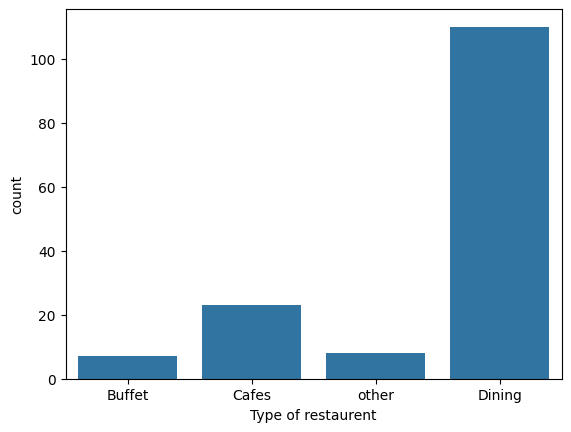

In [7]:
sns.countplot(x=df['listed_in(type)'])
plt.xlabel('Type of restaurent')
plt.show()

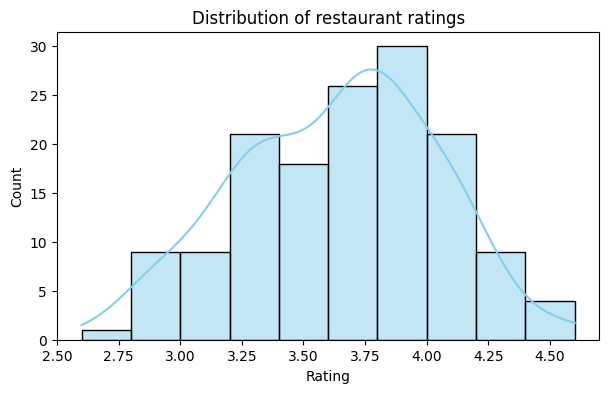

In [8]:
plt.figure(figsize=(7,4))
sns.histplot(df['rate'],bins=10,kde=True,color='skyblue')
plt.title('Distribution of restaurant ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

C:\Users\indiranivas_s\AppData\Local\Temp\ipykernel_20920\2032077043.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='online_order',y='rate',data=df,palette='Set2')


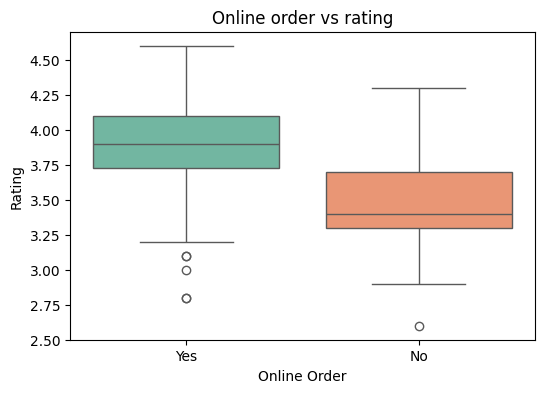

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x='online_order',y='rate',data=df,palette='Set2')
plt.title('Online order vs rating')
plt.xlabel('Online Order')
plt.ylabel('Rating')
plt.show()

<Axes: xlabel='online_order', ylabel='count'>

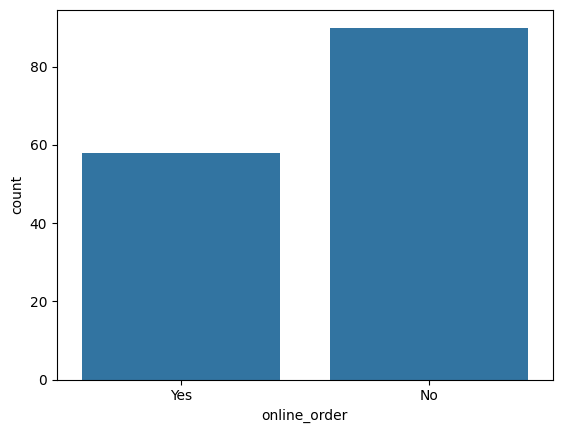

In [10]:
sns.countplot(x=df['online_order'])

C:\Users\indiranivas_s\AppData\Local\Temp\ipykernel_20920\2646612113.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='book_table',y='rate',data=df,palette='Set3')


Text(0, 0.5, 'Rtaing')

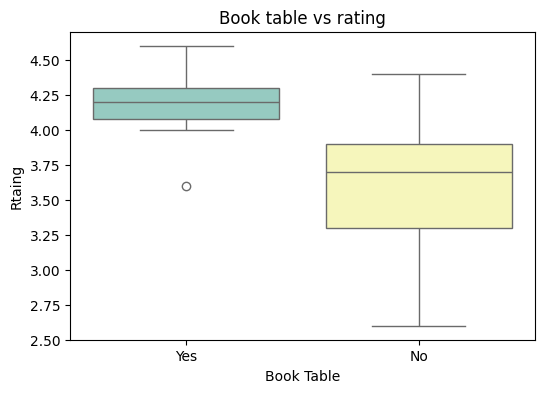

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x='book_table',y='rate',data=df,palette='Set3')
plt.title('Book table vs rating')
plt.xlabel('Book Table')
plt.ylabel('Rtaing')

C:\Users\indiranivas_s\AppData\Local\Temp\ipykernel_20920\3942013164.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='approx_cost(for two people)',y='rate',data=df,palette='purple')


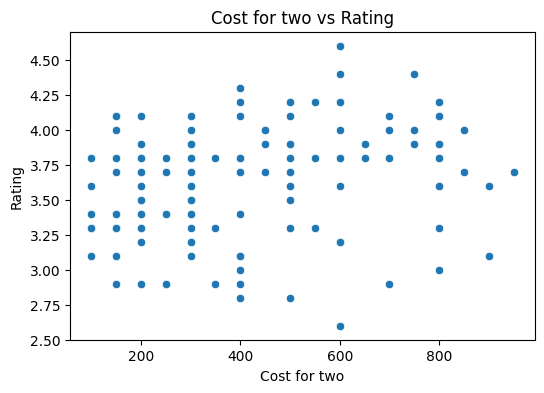

In [12]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='approx_cost(for two people)',y='rate',data=df,palette='purple')
plt.title('Cost for two vs Rating')
plt.xlabel('Cost for two')
plt.ylabel('Rating')
plt.show()

C:\Users\indiranivas_s\AppData\Local\Temp\ipykernel_20920\2591888254.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='listed_in(type)',y='rate',estimator=np.median,data=df,palette='cool')


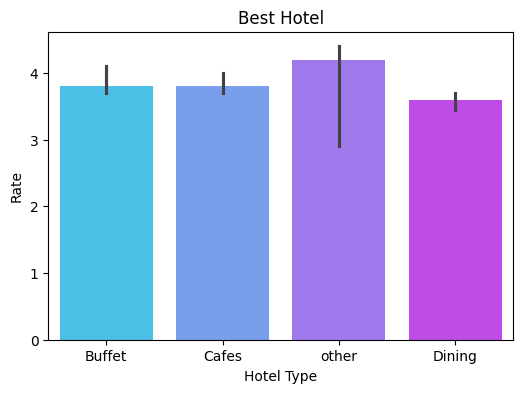

In [13]:
plt.figure(figsize=(6,4))
sns.barplot(x='listed_in(type)',y='rate',estimator=np.median,data=df,palette='cool')
plt.title('Best Hotel')
plt.xlabel('Hotel Type')
plt.ylabel('Rate')
plt.show()

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

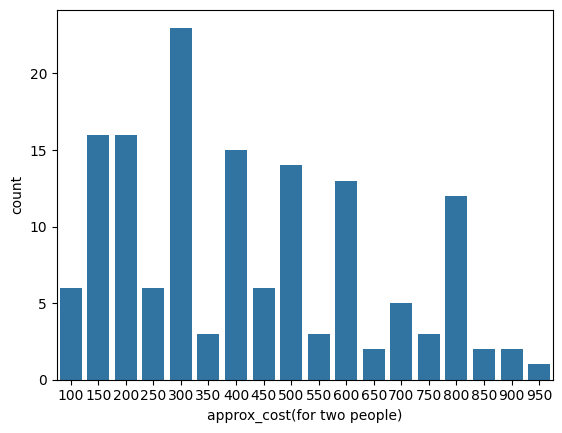

In [14]:
couple_data=df['approx_cost(for two people)']
sns.countplot(x=couple_data)

In [15]:
order_mode_table=pd.crosstab(df['listed_in(type)'],df['online_order'])
print(order_mode_table)

online_order     No  Yes
listed_in(type)         
Buffet            3    4
Cafes             8   15
Dining           77   33
other             2    6


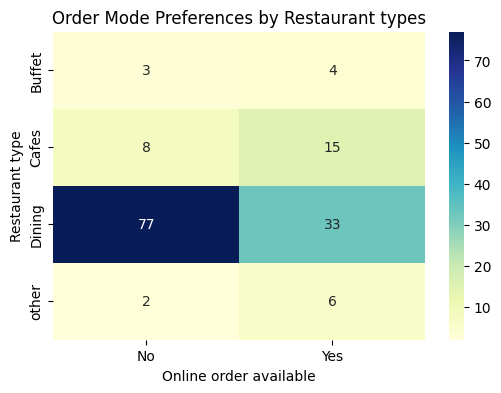

In [16]:
plt.figure(figsize=(6,4))
sns.heatmap(order_mode_table,annot=True,cmap='YlGnBu',fmt='d')
plt.title('Order Mode Preferences by Restaurant types')
plt.xlabel('Online order available')
plt.ylabel('Restaurant type')
plt.show()

<Axes: xlabel='votes', ylabel='rate'>

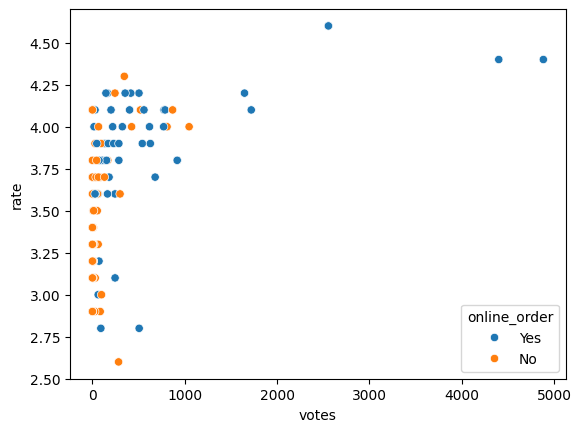

In [17]:
sns.scatterplot(x='votes', y='rate', hue='online_order', data=df)


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [19]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
df['online_order']=le.fit_transform(df['online_order'])
df['book_table']=le.fit_transform(df['book_table'])
df['listed_in(type)']=le.fit_transform(df['listed_in(type)'])

X = df[['online_order','book_table','votes','approx_cost(for two people)','listed_in(type)']]
y = df['rate']

In [20]:
print(X.shape,y.shape)

(148, 5) (148,)


In [21]:
X_train , X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [22]:
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
y_pred = model.predict(X_test)

In [24]:
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_absolute_error(y_test,y_pred))
r2=r2_score(y_test,y_pred)

print("MAE:",mae)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 0.3306095102714301
RMSE: 0.5749865305130462
R2: 0.18264260935486187


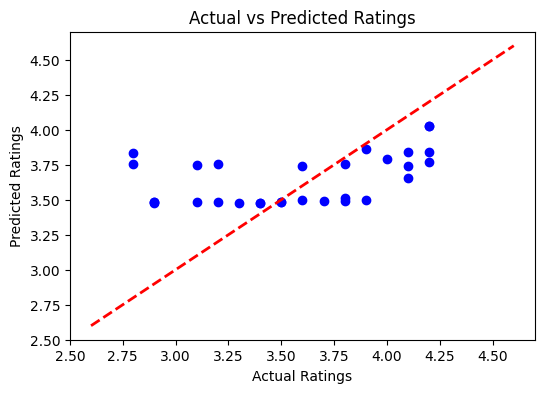

In [25]:
plt.figure(figsize=(6,4))
plt.scatter(y_test,y_pred,color='blue')
plt.plot([y.min(),y.max()],[y.min(),y.max()],'r--',lw=2)
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.title('Actual vs Predicted Ratings')
plt.show()

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
from sklearn.preprocessing import LabelEncoder

df=pd.read_csv('Zomato-data-.csv')
df.columns=df.columns.str.strip()

df['rate'] = df['rate'].astype(str).str.replace('/5', '', regex=False)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')
df['rate'].fillna(df['rate'].mean(), inplace=True)

le=LabelEncoder()
df['online_order']=le.fit_transform(df['online_order'])
df['book_table']=le.fit_transform(df['book_table'])
df['listed_in(type)']=le.fit_transform(df['listed_in(type)'])

X=df[['book_table','votes','rate','approx_cost(for two people)','listed_in(type)']]
y=df['online_order']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=LogisticRegression(max_iter=200)
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

accuracy=accuracy_score(y_test,y_pred)
confusion=confusion_matrix(y_test,y_pred)
classification=classification_report(y_test,y_pred)

print("Accuracy:",accuracy)
print("Confusion Matrix:",confusion_matrix)
print("Classification report:",classification)

Accuracy: 0.6666666666666666
Confusion Matrix: <function confusion_matrix at 0x000002157184B950>
Classification report:               precision    recall  f1-score   support

           0       0.64      0.88      0.74        16
           1       0.75      0.43      0.55        14

    accuracy                           0.67        30
   macro avg       0.69      0.65      0.64        30
weighted avg       0.69      0.67      0.65        30



C:\Users\indiranivas_s\AppData\Local\Temp\ipykernel_20920\732664648.py:12: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['rate'].fillna(df['rate'].mean(), inplace=True)


In [27]:
df.dtypes

name                               str
online_order                     int64
book_table                       int64
rate                           float64
votes                            int64
approx_cost(for two people)      int64
listed_in(type)                  int64
dtype: object

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import LabelEncoder

df=pd.read_csv('Zomato-data-.csv')
df.columns=df.columns.str.strip()

df['rate'] = df['rate'].astype(str).str.replace('/5', '', regex=False)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')
df['rate'].fillna(df['rate'].mean(), inplace=True)

df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '')
    .astype(float)
)

le=LabelEncoder()
df['online_order']=le.fit_transform(df['online_order'].astype(str))
df['book_table']=le.fit_transform(df['book_table'].astype(str))
df['listed_in(type)']=le.fit_transform(df['listed_in(type)'].astype(str))

X=df[['book_table','rate','votes','approx_cost(for two people)','listed_in(type)']]
y=df['online_order']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=DecisionTreeClassifier(criterion='entropy',random_state=42)
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.81      0.68        16
           1       0.62      0.36      0.45        14

    accuracy                           0.60        30
   macro avg       0.61      0.58      0.57        30
weighted avg       0.61      0.60      0.58        30


Confusion Matrix:
 [[13  3]
 [ 9  5]]


C:\Users\indiranivas_s\AppData\Local\Temp\ipykernel_20920\1850167629.py:12: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['rate'].fillna(df['rate'].mean(), inplace=True)


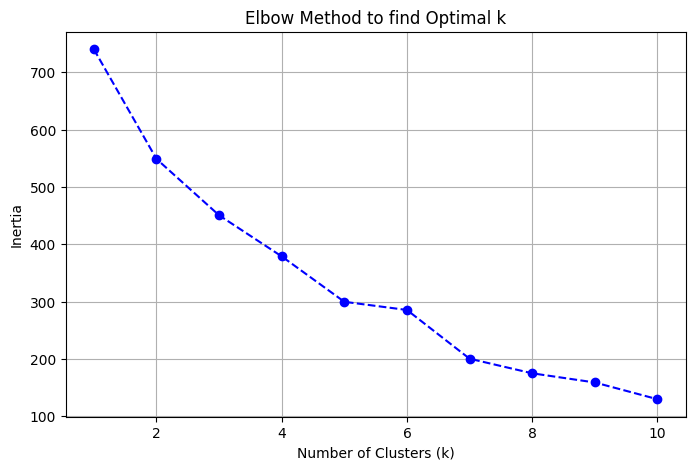

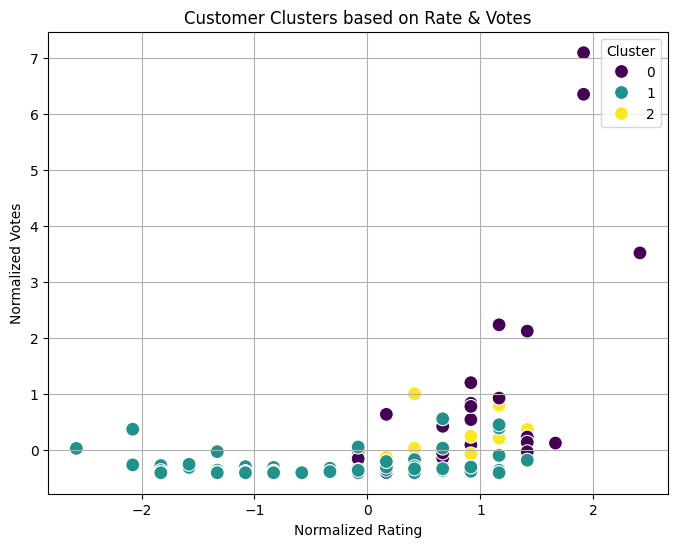


Cluster Centers (Original Scale):

     book_table      rate        votes  approx_cost(for two people)  \
0  2.173913e-01  4.086957  1138.478261                   660.869565   
1 -4.857226e-17  3.478571    63.020408                   314.795918   
2  1.111111e-01  3.807407   253.000000                   587.037037   

   listed_in(type)  
0         2.217391  
1         2.000000  
2         0.740741  

Cluster-wise Summary:

             rate        votes  approx_cost(for two people)
cluster                                                    
0        4.086957  1138.478261                   660.869565
1        3.478571    63.020408                   314.795918
2        3.807407   253.000000                   587.037037


In [29]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv('Zomato-data-.csv')
df.columns = df.columns.str.strip()  

df['rate'] = df['rate'].astype(str).apply(lambda x: x.replace('/5', '') if '/5' in x else x)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

le = LabelEncoder()
df['online_order'] = le.fit_transform(df['online_order'])
df['book_table'] = le.fit_transform(df['book_table'])
df['listed_in(type)'] = le.fit_transform(df['listed_in(type)'])

X = df[['book_table', 'rate', 'votes', 'approx_cost(for two people)', 'listed_in(type)']]

X = X.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method to find Optimal k')
plt.grid(True)
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_scaled[:, 1],  
    y=X_scaled[:, 2],  
    hue=df['cluster'],
    palette='viridis',
    s=100
)
plt.title('Customer Clusters based on Rate & Votes')
plt.xlabel('Normalized Rating')
plt.ylabel('Normalized Votes')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=X.columns)
print("\nCluster Centers (Original Scale):\n")
print(centroids)

print("\nCluster-wise Summary:\n")
print(df.groupby('cluster')[['rate', 'votes', 'approx_cost(for two people)']].mean())
